### 1. Что такое Energy-based тест (E-test)?

**Энергетическое тестирование гипотез** — это современный непараметрический подход, который сравнивает распределения, используя концепцию «статистической энергии» (расстояния между точками).

Представьте точки данных как заряженные частицы:
* $\mathbb{E}[\|X - X'\|]$ и $\mathbb{E}[\|Y - Y'\|]$ — это «внутренняя энергия» (среднее расстояние между частицами внутри одной группы).
* $\mathbb{E}[\|X - Y\|]$ — это «энергия взаимодействия» между группами.

Формула энергетического расстояния:
$$ \mathcal{E}(X, Y) = 2 \mathbb{E}[\|X - Y\|] - \mathbb{E}[\|X - X'\|] - \mathbb{E}[\|Y - Y'\|] $$

Если распределения $X$ и $Y$ идентичны, среднее расстояние *между* группами равно среднему расстоянию *внутри* групп, и $\mathcal{E}(X, Y) = 0$. Если они различаются, $\mathcal{E}(X, Y) > 0$.

**Главное преимущество:** В отличие от T-test или KS-test, которые работают только в 1D, E-test естественным образом обобщается на многомерные данные ($\mathbb{R}^d$) и является *состоятельным против любых альтернатив* (он заметит разницу в среднем, дисперсии, асимметрии или ковариации).

### 2. Дизайн бенчмарка


Мы проведём **метод Монте-Карло**: сгенерируем **1000 независимых экспериментов** для каждого из **9 сценариев** (размер выборки $N=100$) и посчитаем долю случаев, когда тест отверг нулевую гипотезу ($p < 0.05$). Для пермутационных тестов (Energy, MMD) используется $B=500$ перестановок.

---

#### 9 Сценариев

#### Базовые 1D-сценарии

| # | Название | Распределения | Что проверяем |
|---|----------|---------------|---------------|
| 1 | **Null** (контроль) | $X \sim \mathcal{N}(0, 1)$, $Y \sim \mathcal{N}(0, 1)$ | Калибровка: ожидаем ~5% отвержений (уровень $\alpha$) |
| 2 | **Mean Shift** | $X \sim \mathcal{N}(0, 1)$, $Y \sim \mathcal{N}(0.5, 1)$ | Сдвиг среднего. *Ожидаем:* T-test, MW, Hotelling — высокая мощность |
| 3 | **Variance Shift** | $X \sim \mathcal{N}(0, 1)$, $Y \sim \mathcal{N}(0, 2)$ | Изменение дисперсии при равных средних. *Ожидаем:* T-test и MW «ослепнут», Levene и Energy сработают |
| 4 | **Shape Shift** | $X \sim \mathcal{N}(0, 1)$, $Y \sim Uniform(-\sqrt{3}, \sqrt{3})$ | Средние и дисперсии **идентичны**, отличается форма. *Ожидаем:* T-test и MW провалятся, KS, AD, Energy, MMD — умеренная мощность |

#### Усложнённые 1D-сценарии

| # | Название | Распределения | Что проверяем |
|---|----------|---------------|---------------|
| 5 | **Outliers** | $X \sim \mathcal{N}(0, 1)$, $Y$ — нормальное с 10% выбросов ($\times 10$) | Устойчивость к аномалиям. *Ожидаем:* T-test деградирует, Energy/MMD устойчивее |
| 6 | **Multimodal** | $X \sim \mathcal{N}(0, 1)$, $Y \sim 0.5\cdot\mathcal{N}(-2,1) + 0.5\cdot\mathcal{N}(+2,1)$ | Бимодальность при близком среднем. *Ожидаем:* T-test слеп, KS/AD/Energy/MMD должны увидеть |
| 7 | **Skewness** | $X \sim \mathcal{N}(0, 1)$, $Y \sim Exp(1) - 1$ | Асимметрия. *Ожидаем:* T-test частично слеп, KS/AD/Energy сработают |

#### Многомерные и структурные сценарии

| # | Название | Распределения | Что проверяем |
|---|----------|---------------|---------------|
| 8 | **10D Covariance** | $X \sim \mathcal{N}(\mathbf{0}, I_{10})$, $Y \sim \mathcal{N}(\mathbf{0}, \Sigma)$, где $\Sigma_{ij} = 0.5$ при $i \neq j$ | Разница в корреляционной структуре. *Ожидаем:* 1D-тесты (на первой маргинальной компоненте) слепы, Hotelling/Energy/MMD увидят |
| 9 | **Unbalanced** | $X \sim \mathcal{N}(0, 1),\; n=30$; $Y \sim \mathcal{N}(0.5, 1),\; n=100$ | Несбалансированные выборки + сдвиг среднего. *Ожидаем:* проверка устойчивости всех тестов к неравенству объёмов |

---

#### 8 Тестов

| Тест | Тип | На что чувствителен |
|------|-----|---------------------|
| **T-test** | параметрический | Сдвиг среднего (при равных дисперсиях) |
| **Mann-Whitney** | непараметрический | Сдвиг медианы / стохастическое доминирование |
| **KS-test** | непараметрический | Любые различия в CDF |
| **Anderson-Darling** | непараметрический | Различия в CDF, особенно в **хвостах** |
| **Levene** | параметрический/непар. | Равенство дисперсий |
| **Hotelling T²** | параметрический | Сдвиг среднего в многомерном случае |
| **Energy Test** | непараметрический (пермутационный) | Любые различия распределений (включая многомерные) |
| **MMD** | ядерный (пермутационный) | Любые различия (чувствителен к выбору ядра) |

---

#### Что визуализируем

1. **Heatmap мощности** — доля отвержений $H_0$ по каждому тесту и сценарию.
2. **Heatmap runtime** — среднее время выполнения теста (мс).
3. **Power Curves** — рост мощности T-test, MW, KS, AD, Energy, MMD при увеличении сдвига среднего $\delta \in [0, 3]$.
4. **Гистограммы p-values** — для 3 ключевых сценариев (Null, Variance Shift, Multimodal) × 4 теста: форма гистограммы показывает, насколько хорошо тест «видит» различие (равномерная = слеп, скошенная влево = мощный).

In [1]:
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import cdist
import time
import warnings
warnings.filterwarnings('ignore')

In [2]:
# --- 1. Anderson-Darling (sensitive to tails, more powerful than KS) ---
def anderson_darling_test(x, y):
    return stats.anderson_ksamp([x, y]).pvalue

# --- 2. Levene's test (test for equality of variances) ---
def levene_test(x, y):
    return stats.levene(x, y).pvalue

# --- 3. Hotelling's T² (multivariate analogue of T-test) ---
def hotelling_test(x, y):
    if x.ndim == 1:
        x, y = x.reshape(-1, 1), y.reshape(-1, 1)
    n1, n2 = len(x), len(y)
    p = x.shape[1]
    mean_diff = x.mean(axis=0) - y.mean(axis=0)
    S_pooled = ((n1 - 1) * np.cov(x, rowvar=False) + (n2 - 1) * np.cov(y, rowvar=False)) / (n1 + n2 - 2)
    try:
        T2 = (n1 * n2 / (n1 + n2)) * mean_diff @ np.linalg.inv(S_pooled) @ mean_diff
        F_stat = (n1 + n2 - p - 1) / ((n1 + n2 - 2) * p) * T2
        return 1 - stats.f.cdf(F_stat, p, n1 + n2 - p - 1)
    except np.linalg.LinAlgError:
        return 1.0  # degenerate covariance

# --- 4. MMD (Maximum Mean Discrepancy) with Gaussian kernel ---
def mmd_test(x, y, n_perms=100, gamma=None):
    if x.ndim == 1:
        x, y = x.reshape(-1, 1), y.reshape(-1, 1)
    if gamma is None:
        # Median heuristic for kernel bandwidth selection
        dists = cdist(x, y, 'sqeuclidean')
        gamma = 1.0 / (2 * np.median(dists) + 1e-8)
    
    def mmd2(X, Y):
        K_xx = np.exp(-gamma * cdist(X, X, 'sqeuclidean'))
        K_yy = np.exp(-gamma * cdist(Y, Y, 'sqeuclidean'))
        K_xy = np.exp(-gamma * cdist(X, Y, 'sqeuclidean'))
        m, n = len(X), len(Y)
        np.fill_diagonal(K_xx, 0)
        np.fill_diagonal(K_yy, 0)
        return K_xx.sum()/(m*(m-1)) + K_yy.sum()/(n*(n-1)) - 2*K_xy.sum()/(m*n)
    
    obs = mmd2(x, y)
    combined = np.vstack([x, y])
    n = len(x)
    count = sum(1 for _ in range(n_perms) 
                if mmd2(combined[np.random.permutation(len(combined))][:n], 
                        combined[np.random.permutation(len(combined))][n:]) >= obs)
    return (count + 1) / (n_perms + 1)

# --- 5. Energy Test (from previous cells) ---
def energy_stat(x, y):
    if x.ndim == 1:
        diff_xy, diff_xx, diff_yy = x[:, None]-y[None, :], x[:, None]-x[None, :], y[:, None]-y[None, :]
    else:
        diff_xy, diff_xx, diff_yy = x[:, None, :]-y[None, :, :], x[:, None, :]-x[None, :, :], y[:, None, :]-y[None, :, :]
    return 2*np.linalg.norm(diff_xy, axis=-1).mean() - np.linalg.norm(diff_xx, axis=-1).mean() - np.linalg.norm(diff_yy, axis=-1).mean()

def energy_test(x, y, n_perms=100):
    obs_stat = energy_stat(x, y)
    combined = np.concatenate([x, y]) if x.ndim == 1 else np.vstack([x, y])
    n = len(x)
    count = sum(1 for _ in range(n_perms) 
                if energy_stat(np.random.permutation(combined)[:n], 
                               np.random.permutation(combined)[n:]) >= obs_stat)
    return (count + 1) / (n_perms + 1)

In [3]:
N_SIMS = 100
N_SAMPLES = 100
ALPHA = 0.05
N_PERMS = 50

# Register all tests
TESTS = {
    'T-test': lambda x, y: stats.ttest_ind(x, y).pvalue,
    'Mann-Whitney': lambda x, y: stats.mannwhitneyu(x, y, alternative='two-sided').pvalue,
    'KS-test': lambda x, y: stats.ks_2samp(x, y).pvalue,
    'Anderson-Darling': anderson_darling_test,
    'Levene': levene_test,
    'Hotelling T²': hotelling_test,
    'Energy': lambda x, y: energy_test(x, y, n_perms=N_PERMS),
    'MMD': lambda x, y: mmd_test(x, y, n_perms=N_PERMS),
}

In [4]:
def generate_scenarios(n_sims, n_samples):
    """9 scenarios instead of 5."""
    np.random.seed(42)
    sc = {}
    
    # Basic 1D
    sc['1. Null'] = (np.random.randn(n_sims, n_samples), np.random.randn(n_sims, n_samples), 1)
    sc['2. Mean Shift'] = (np.random.randn(n_sims, n_samples), np.random.randn(n_sims, n_samples) + 0.5, 1)
    sc['3. Variance Shift'] = (np.random.randn(n_sims, n_samples), np.random.randn(n_sims, n_samples) * 2.0, 1)
    sc['4. Shape Shift'] = (np.random.randn(n_sims, n_samples), np.random.uniform(-np.sqrt(3), np.sqrt(3), (n_sims, n_samples)), 1)
    
    # NEW scenarios
    # 5. Outliers: add 10% strong outliers to Y
    y_out = np.random.randn(n_sims, n_samples)
    mask = np.random.rand(n_sims, n_samples) < 0.1
    y_out[mask] *= 10
    sc['5. Outliers'] = (np.random.randn(n_sims, n_samples), y_out, 1)
    
    # 6. Multimodal: Y is a mixture of two Gaussians
    y_mm = np.where(np.random.rand(n_sims, n_samples) > 0.5,
                    np.random.randn(n_sims, n_samples) - 2,
                    np.random.randn(n_sims, n_samples) + 2)
    sc['6. Multimodal'] = (np.random.randn(n_sims, n_samples), y_mm, 1)
    
    # 7. Skewness: Y is exponential (shifted by 1 for comparability)
    sc['7. Skewness'] = (np.random.randn(n_sims, n_samples), np.random.exponential(1, (n_sims, n_samples)) - 1, 1)
    
    # 8. High-D (10D): X independent, Y correlated
    d = 10
    cov = np.eye(d) + 0.5 * (1 - np.eye(d))
    sc['8. 10D Covariance'] = (np.random.randn(n_sims, n_samples, d), 
                                np.random.multivariate_normal(np.zeros(d), cov, (n_sims, n_samples)), d)
    
    # 9. Unbalanced: X - 30 points, Y - 100 points
    sc['9. Unbalanced'] = (np.random.randn(n_sims, 30), np.random.randn(n_sims, 100) + 0.5, 1)
    
    return sc

In [5]:
# --- Running benchmark with timing ---
def run_benchmark(scenarios, tests):
    results = []
    timings = {name: [] for name in tests}
    
    for name, (x_all, y_all, dim) in scenarios.items():
        row = {'Scenario': name}
        for t_name, t_func in tests.items():
            rejections = 0
            times = []
            for i in range(len(x_all)):
                x_i, y_i = x_all[i], y_all[i]
                # 1D tests on multidimensional data - marginal distribution
                if dim > 1 and t_name in ['T-test', 'Mann-Whitney', 'KS-test', 'Anderson-Darling', 'Levene']:
                    x_i, y_i = x_i[:, 0], y_i[:, 0]
                
                t0 = time.perf_counter()
                try:
                    p = t_func(x_i, y_i)
                    if p < ALPHA:
                        rejections += 1
                except Exception:
                    p = 1.0
                times.append(time.perf_counter() - t0)
                
            row[t_name] = rejections / len(x_all)
            timings[t_name].append(np.mean(times) * 1000)  # in ms
        results.append(row)
    
    return pd.DataFrame(results), pd.DataFrame(timings, index=list(scenarios.keys()))

scenarios = generate_scenarios(N_SIMS, N_SAMPLES)
df_results, df_timings = run_benchmark(scenarios, TESTS)

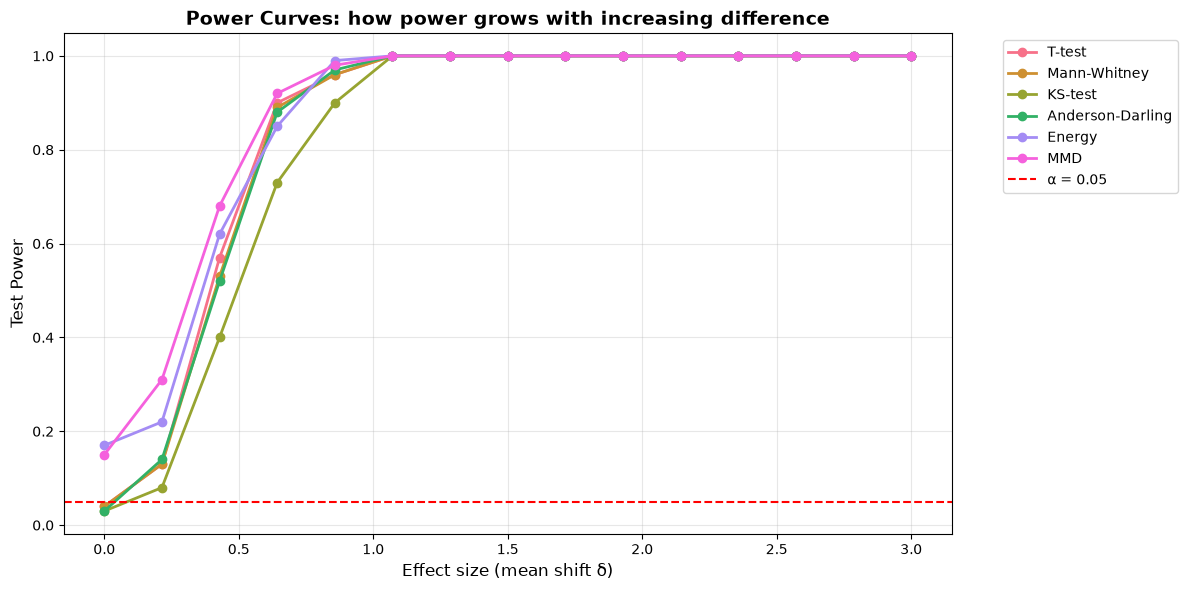

In [6]:
def power_curve(test_func, effect_sizes, n_samples=50, n_sims=100, n_perms=50):
    """Plots the power curve for a single test."""
    powers = []
    np.random.seed(42)
    for delta in effect_sizes:
        rejections = 0
        for _ in range(n_sims):
            x = np.random.randn(n_samples)
            y = np.random.randn(n_samples) + delta
            if test_func(x, y) < ALPHA:
                rejections += 1
        powers.append(rejections / n_sims)
    return powers

effect_sizes = np.linspace(0, 3, 15)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("husl", len(TESTS))
for (t_name, t_func), color in zip(TESTS.items(), colors):
    if t_name in ['Levene', 'Hotelling T²']:  # these are not for mean shift
        continue
    powers = power_curve(t_func, effect_sizes, n_sims=100, n_perms=30)
    plt.plot(effect_sizes, powers, marker='o', label=t_name, color=color, linewidth=2)

plt.axhline(ALPHA, color='red', linestyle='--', label=f'α = {ALPHA}')
plt.xlabel('Effect size (mean shift δ)', fontsize=12)
plt.ylabel('Test Power', fontsize=12)
plt.title('Power Curves: how power grows with increasing difference', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

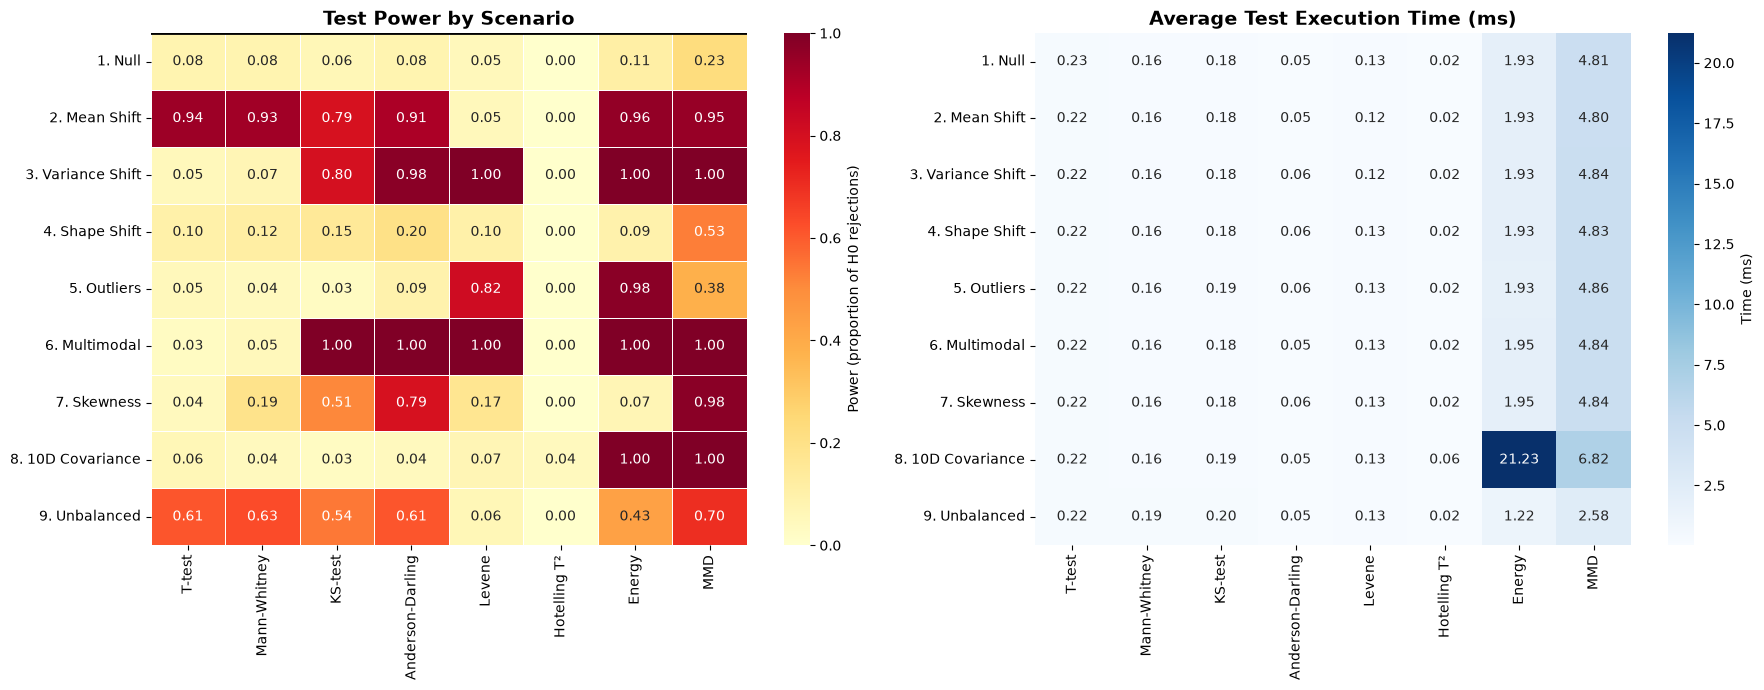

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Power heatmap
test_cols = list(TESTS.keys())
heatmap_data = df_results.set_index('Scenario')[test_cols].astype(float)
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Power (proportion of H0 rejections)'},
            vmin=0, vmax=1, linewidths=0.5)
axes[0].set_title('Test Power by Scenario', fontsize=14, fontweight='bold')
axes[0].axhline(y=0, color='black', linewidth=2)  # border
axes[0].set_ylabel('')

# Runtime
df_timings_log = np.log10(df_timings + 1e-6)  # log scale for better visualization
sns.heatmap(df_timings, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1], cbar_kws={'label': 'Time (ms)'})
axes[1].set_title('Average Test Execution Time (ms)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()